# **DEEP LEARNING (Assignment-3)**

---------------------------
---------------------------

### **Part 1: The Bottleneck Challenge (Undercomplete AE)**

In this part, we focus on understanding how an autoencoder compresses high-dimensional image data into a compact latent space & then reconstructs it:

-> *First, we implement a symmetric Autoencoder for MNIST with encoder architecture 784 → 128 → 64 → N and decoder architecture N → 64 → 128 → 784.*

-> *Then same model is trained using two different bottleneck sizes, N=2 and N=32, to study how latent-space size affects reconstruction quality.*

-> *Finally we compare a few original vs. reconstructed digit images for both bottleneck settings to visually examine the effect of stronger vs. weaker compression.*

Observation: Images reconstructed from N=32 are generally clearer and preserve more digit details, while N=2 reconstructions appear blurrier or less accurate because the network must compress the entire image into only two latent values, causing greater information loss.

---------------------------
---------------------------

In [1]:
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 30
lr = 1e-3
data_path = "./mnist_data"

transform = transforms.ToTensor()
train_data = datasets.MNIST(root=data_path, train=True, download=True, transform=transform)
test_data = datasets.MNIST(root=data_path, train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, bottleneck)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

def train_model(n):
    model = Autoencoder(n).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss(reduction="sum")
    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, _ in train_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)

            optimizer.zero_grad()
            x_hat = model(x)
            loss = criterion(x_hat, x_flat)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader.dataset)
        losses.append(epoch_loss)
        print(f"N={n} | Epoch {epoch + 1:02d}/{epochs} | Reconstruction Loss: {epoch_loss:.4f}")

    return model, losses

In [3]:
model_2, losses_2 = train_model(2)
model_32, losses_32 = train_model(32)

N=2 | Epoch 01/30 | Reconstruction Loss: 198.0878
N=2 | Epoch 02/30 | Reconstruction Loss: 161.7620
N=2 | Epoch 03/30 | Reconstruction Loss: 154.2697
N=2 | Epoch 04/30 | Reconstruction Loss: 150.8103
N=2 | Epoch 05/30 | Reconstruction Loss: 148.4455
N=2 | Epoch 06/30 | Reconstruction Loss: 146.5749
N=2 | Epoch 07/30 | Reconstruction Loss: 145.0420
N=2 | Epoch 08/30 | Reconstruction Loss: 143.8900
N=2 | Epoch 09/30 | Reconstruction Loss: 142.7758
N=2 | Epoch 10/30 | Reconstruction Loss: 141.8956
N=2 | Epoch 11/30 | Reconstruction Loss: 141.1332
N=2 | Epoch 12/30 | Reconstruction Loss: 140.3900
N=2 | Epoch 13/30 | Reconstruction Loss: 139.7676
N=2 | Epoch 14/30 | Reconstruction Loss: 139.0914
N=2 | Epoch 15/30 | Reconstruction Loss: 138.5497
N=2 | Epoch 16/30 | Reconstruction Loss: 138.0771
N=2 | Epoch 17/30 | Reconstruction Loss: 137.7114
N=2 | Epoch 18/30 | Reconstruction Loss: 137.3604
N=2 | Epoch 19/30 | Reconstruction Loss: 136.9474
N=2 | Epoch 20/30 | Reconstruction Loss: 136.5654


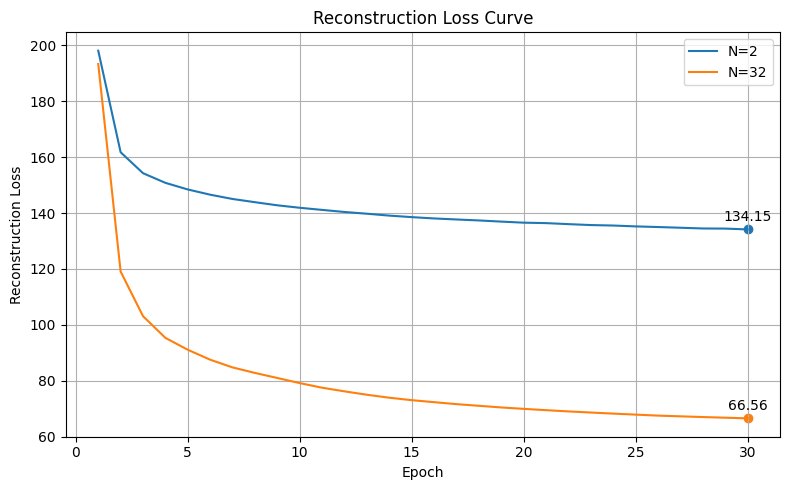

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses_2, label="N=2")
plt.plot(range(1, epochs + 1), losses_32, label="N=32")
plt.scatter(30, losses_2[29])
plt.scatter(30, losses_32[29])
plt.text(30, losses_2[29] + 2, f"{losses_2[29]:.2f}", ha="center", va="bottom", fontsize=10)
plt.text(30, losses_32[29] + 2, f"{losses_32[29]:.2f}", ha="center", va="bottom", fontsize=10)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join("loss_curve.png"), dpi=600, bbox_inches="tight")
plt.show()

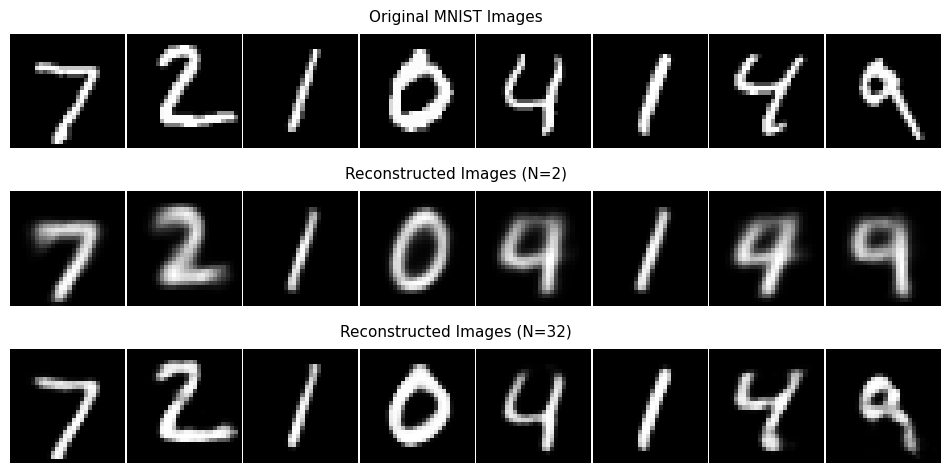

In [5]:
x, _ = next(iter(test_loader))
x = x[:8].to(device)

with torch.no_grad():
    x_hat_2 = model_2(x).view(-1, 1, 28, 28).cpu()
    x_hat_32 = model_32(x).view(-1, 1, 28, 28).cpu()

x = x.cpu()

fig, axes = plt.subplots(3, 8, figsize=(12, 5.6))
rows = [x, x_hat_2, x_hat_32]
row_labels = ["Original MNIST Images", "Reconstructed Images (N=2)", "Reconstructed Images (N=32)"]

for r in range(3):
    for c in range(8):
        axes[r, c].imshow(rows[r][c].squeeze(), cmap="gray")
        axes[r, c].axis("off")

    axes[r, 0].text(
        3.9, 1.08, row_labels[r],
        transform=axes[r, 0].transAxes,
        ha="center", va="bottom", fontsize=11
    )

plt.subplots_adjust(wspace=0.02, hspace=0.35)
plt.savefig(os.path.join("reconstruction_comparison.png"), dpi=600, bbox_inches="tight")
plt.show()

# Deep Learning Assignment – Part 2: Denoising Autoencoder (DAE)

## Question 2.1: The Denoising Autoencoder

**Goal:** Force the network to learn useful, robust features by corrupting the input.  
**Dataset:** Tiny-ImageNet-10  
**Architecture:** Convolutional Autoencoder (CAE) using `Conv2d` and `ConvTranspose2d`  
**Optimizer:** Adam  
**Loss:** Mean Squared Error (MSE)  
**Epochs:** 30  

### Steps:
1. Load & preprocess Tiny-ImageNet-10
2. Add **Gaussian noise** or **Salt & Pepper noise** to the images
3. Train the CAE to reconstruct the **clean** image from the **noisy** input
4. Visualise the **Reconstruction Trio**: Original | Noisy | Denoised
5. Plot the **Reconstruction Loss** curve over 30 epochs

## 1. Imports & Setup

In [26]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Dataset – Tiny-ImageNet-10

Tiny-ImageNet-10 is a 10-class subset of Tiny-ImageNet (64×64 RGB images).  
The cell below **auto-downloads** the full Tiny-ImageNet archive and keeps only the
first 10 classes (wnids), so the notebook is fully self-contained.


In [27]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_ROOT   = './tiny-imagenet-200'   # will be created if absent
BATCH_SIZE  = 64
IMG_SIZE    = 64           # Tiny-ImageNet images are 64×64
NUM_EPOCHS  = 30
LR          = 1e-3
NUM_CLASSES = 10           # we use only the first 10 wnid classes

# Training on Gaussian noise only for sharper reconstructions.
# Options: 'gaussian' | 'salt_pepper' | 'both'
NOISE_TYPE  = 'gaussian'

GAUSS_STD   = 0.1       # std for Gaussian noise  (images in [0,1])
SP_PROB     = 0.02         # proportion of pixels flipped for Salt & Pepper

In [28]:
# ── Download Tiny-ImageNet (if not present) ───────────────────────────────────
import urllib.request, zipfile, shutil

ZIP_URL  = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
ZIP_PATH = './tiny-imagenet-200.zip'

if not os.path.isdir(DATA_ROOT):
    print('Downloading Tiny-ImageNet-200 (~235 MB)…')
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH,
        reporthook=lambda b, bs, t: print(f'  {min(b*bs, t)/1e6:.1f}/{t/1e6:.1f} MB', end='\r'))
    print('\nExtracting…')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)
    print('Done.')
else:
    print('Dataset directory already exists – skipping download.')

Dataset directory already exists – skipping download.


In [29]:
# ── Select 10 classes ────────────────────────────────────────────────────────
train_dir = os.path.join(DATA_ROOT, 'train')
all_wnids = sorted(os.listdir(train_dir))           # 200 folders
selected_wnids = all_wnids[:NUM_CLASSES]            # first 10 classes

# Load human-readable labels
words_file = os.path.join(DATA_ROOT, 'words.txt')
wnid2name  = {}
if os.path.isfile(words_file):
    with open(words_file) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                wnid2name[parts[0]] = parts[1].split(',')[0].strip()

print(f'Selected {NUM_CLASSES} classes:')
for i, w in enumerate(selected_wnids):
    print(f'  [{i}] {w} → {wnid2name.get(w, "?")}')

Selected 10 classes:
  [0] n01443537 → goldfish
  [1] n01629819 → European fire salamander
  [2] n01641577 → bullfrog
  [3] n01644900 → tailed frog
  [4] n01698640 → American alligator
  [5] n01742172 → boa constrictor
  [6] n01768244 → trilobite
  [7] n01770393 → scorpion
  [8] n01774384 → black widow
  [9] n01774750 → tarantula


## 3. Custom Dataset Class

In [30]:
class TinyImageNet10(Dataset):
    """
    A subset of Tiny-ImageNet containing only `selected_wnids` classes.
    Returns (image_tensor, label) pairs.
    Images are 64×64 RGB, normalised to [0, 1].
    """

    def __init__(self, root, wnids, split='train', transform=None):
        """
        Args:
            root     : path to tiny-imagenet-200/
            wnids    : list of wnid folder names to include
            split    : 'train' – reads from <root>/train/<wnid>/images/
            transform: torchvision transforms
        """
        self.transform = transform
        self.samples   = []   # list of (path, label_idx)

        for label_idx, wnid in enumerate(wnids):
            img_dir = os.path.join(root, split, wnid, 'images')
            if not os.path.isdir(img_dir):
                continue
            for fname in sorted(os.listdir(img_dir)):
                if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                    self.samples.append((os.path.join(img_dir, fname), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')   # ensure 3-channel
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Transforms ───────────────────────────────────────────────────────────────
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # → [0, 1]
])

# Build full dataset from train split; split into train / val
full_dataset = TinyImageNet10(
    root=DATA_ROOT, wnids=selected_wnids,
    split='train', transform=base_transform
)

val_size   = int(0.15 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

#Set num_workers=0 to avoid BrokenPipeError on Windows and in Jupyter/Colab environments where multiprocessing workers are not supported.
# If running on Linux with many CPU cores, you may increase this (e.g. 4).
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')
print(f'Batches/epoch : {len(train_loader)}')

Train samples : 4250
Val   samples : 750
Batches/epoch : 67


## 4. Noise Functions

We implement **two** independent noise types and expose a single
`add_noise(x, noise_type)` helper so the training loop stays clean.

| Noise type | Description |
|---|---|
| Gaussian | Each pixel is shifted by `N(0, σ²)`; result clipped to `[0,1]` |
| Salt & Pepper | A fraction `p` of randomly chosen pixels is set to 0 or 1 |

Noise sanity check (first training image):


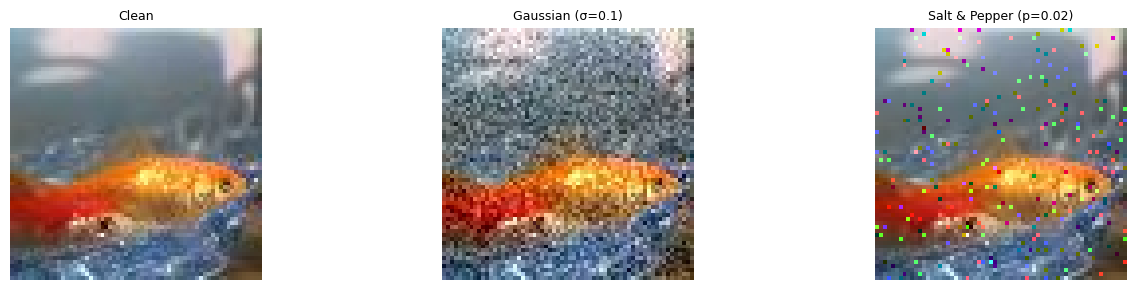

In [31]:
def add_gaussian_noise(x: torch.Tensor, std: float = 0.2) -> torch.Tensor:
    """
    Add zero-mean Gaussian noise to a batch of images.

    Args:
        x   : clean images, shape (B, C, H, W), values in [0, 1]
        std : standard deviation of the Gaussian noise

    Returns:
        Noisy images clipped to [0, 1]
    """
    noise = torch.randn(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device) * std
    return torch.clamp(x + noise, 0.0, 1.0)


def add_salt_pepper_noise(x: torch.Tensor, prob: float = 0.05) -> torch.Tensor:
    """
    Add Salt-and-Pepper noise to a batch of images.

    Args:
        x    : clean images, shape (B, C, H, W), values in [0, 1]
        prob : fraction of pixels to corrupt
               (prob/2 set to 0 – pepper, prob/2 set to 1 – salt)

    Returns:
        Noisy images in [0, 1]
    """
    noisy = x.clone()
    # Random mask for all pixels
    rand  = torch.rand_like(x)
    # Salt: set to 1
    noisy[rand < prob / 2]                     = 1.0
    # Pepper: set to 0
    noisy[(rand >= prob / 2) & (rand < prob)]  = 0.0
    return noisy


def add_noise(x: torch.Tensor, noise_type: str = 'gaussian') -> torch.Tensor:
    """
    Unified noise interface.

    Args:
        x          : clean images tensor
        noise_type : 'gaussian' | 'salt_pepper' | 'both'

    Returns:
        Noisy images tensor
    """
    if noise_type == 'gaussian':
        return add_gaussian_noise(x, std=GAUSS_STD)
    elif noise_type == 'salt_pepper':
        return add_salt_pepper_noise(x, prob=SP_PROB)
    elif noise_type == 'both':
        # Apply Gaussian first, then Salt & Pepper
        return add_salt_pepper_noise(
            add_gaussian_noise(x, std=GAUSS_STD), prob=SP_PROB)
    else:
        raise ValueError(f"Unknown noise_type: '{noise_type}'")


# ── Quick sanity-check visualisation ─────────────────────────────────────────
sample_imgs, _ = next(iter(train_loader))
sample_clean   = sample_imgs[:4]                              # 4 clean images
sample_gauss   = add_gaussian_noise(sample_clean, GAUSS_STD)
sample_sp      = add_salt_pepper_noise(sample_clean, SP_PROB)

def show_row(tensors, titles, figsize=(14, 3)):
    fig, axes = plt.subplots(1, len(tensors), figsize=figsize)
    for ax, t, title in zip(axes, tensors, titles):
        ax.imshow(t.permute(1, 2, 0).cpu().numpy())
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Noise sanity check (first training image):')
show_row(
    [sample_clean[0], sample_gauss[0], sample_sp[0]],
    ['Clean', f'Gaussian (σ={GAUSS_STD})', f'Salt & Pepper (p={SP_PROB})']
)

## 5. Convolutional Autoencoder Architecture

We use a **Convolutional Autoencoder (CAE)** as required for Tiny-ImageNet-10:

| Block | Layers | Output shape |
|---|---|---|
| **Encoder** | Conv2d × 3 (stride 2) | (B, 128, 8, 8) |
| **Bottleneck** | Latent tensor | (B, 128, 8, 8) |
| **Decoder** | ConvTranspose2d × 3 (stride 2) | (B, 3, 64, 64) |

Each encoder block: `Conv2d → BatchNorm → ReLU`  
Each decoder block: `ConvTranspose2d → BatchNorm → ReLU` (last block uses `Sigmoid`)

In [32]:
class ConvBlock(nn.Module):
    """Conv2d + BatchNorm2d + ReLU (for encoder)."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=2, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class ConvTBlock(nn.Module):
    """ConvTranspose2d + BatchNorm2d + ReLU (for decoder)."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=2,
                 padding=1, output_padding=1, last=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, kernel,
                               stride=stride, padding=padding,
                               output_padding=output_padding, bias=False),
        ]
        if last:
            layers.append(nn.Sigmoid())        # output in [0, 1]
        else:
            layers += [nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder for 64×64 RGB images.

    Encoder path  : 3 → 32 → 64 → 128 → 256  (spatial: 64→32→16→8→4)
    Decoder path  : 256 → 128 → 64 → 32 → 3  (spatial: 4→8→16→32→64)
    """

    def __init__(self):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        # Input: (B, 3, 64, 64)
        self.encoder = nn.Sequential(
            ConvBlock(3,   32),    # → (B,  32, 32, 32)
             ConvBlock(32,  64),    # → (B,  64, 16, 16)
             ConvBlock(64, 128),    # → (B, 128,  8,  8) 
        )

        # ── Decoder ──────────────────────────────────────────────────────────
        # Input: (B, 128, 8, 8)
        self.decoder = nn.Sequential(
            ConvTBlock(128,  64),              # → (B,  64, 16, 16)
            ConvTBlock(64,   32),              # → (B,  32, 32, 32)
            ConvTBlock(32,    3, last=True),   # → (B,   3, 64, 64)
        )

    def encode(self, x):
        """Return the latent representation."""
        return self.encoder(x)

    def decode(self, z):
        """Reconstruct from latent representation."""
        return self.decoder(z)

    def forward(self, x):
        """Encode then decode."""
        return self.decode(self.encode(x))


# ── Model summary ─────────────────────────────────────────────────────────────
model = ConvAutoencoder().to(DEVICE)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

# Verify output shape
dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input shape  : {dummy.shape}')
print(f'Output shape : {out.shape}')
assert out.shape == dummy.shape, 'Shape mismatch – check architecture!'

ConvAutoencoder(
  (encoder): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
  )
  (decoder): Sequential(
    (0): ConvTBlock(
      (block): Sequential(
        (0): ConvTranspose2d(128, 64, kernel_size

## 6. Training the Denoising Autoencoder

**Key idea:** the model receives a **noisy image** as input but is trained to
minimise the MSE against the **clean image**.  This forces it to learn the
underlying structure of the data rather than memorising noise.

```
Noisy image  ──► Encoder ──► Latent  ──► Decoder ──► Reconstructed image
                                                              │
                                 MSE loss with Clean image ◄──┘
```

In [33]:
# ── Loss & Optimiser ──────────────────────────────────────────────────────────
criterion = nn.MSELoss()           # Mean Squared Error, as required
optimizer = optim.Adam(model.parameters(), lr=LR)

# Optional: cosine LR annealing for smoother convergence
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def run_epoch(loader, train=True):
    """
    Run one epoch of training or validation.

    Args:
        loader : DataLoader
        train  : if True, compute gradients and update weights

    Returns:
        Average MSE loss over the epoch
    """
    model.train() if train else model.eval()
    total_loss = 0.0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for clean_imgs, _ in loader:
            clean_imgs = clean_imgs.to(DEVICE)

            # ① Corrupt the input
            noisy_imgs = add_noise(clean_imgs, NOISE_TYPE)

            # ② Forward pass: noisy → reconstructed
            reconstructed = model(noisy_imgs)

            # ③ Loss: reconstructed vs. CLEAN target
            loss = criterion(reconstructed, clean_imgs)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * clean_imgs.size(0)

    return total_loss / len(loader.dataset)


# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'Training Denoising CAE for {NUM_EPOCHS} epochs  '
      f'(noise={NOISE_TYPE}, device={DEVICE})\n')
print(f'{"Epoch":>6}  {"Train MSE":>12}  {"Val MSE":>10}  {"LR":>10}')
print('-' * 46)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    # Save best model checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_dae.pth')

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6}  {tr_loss:>12.6f}  {val_loss:>10.6f}  {current_lr:>10.2e}')

print(f'\nTraining complete. Best validation MSE: {best_val_loss:.6f}')

Training Denoising CAE for 30 epochs  (noise=gaussian, device=cpu)

 Epoch     Train MSE     Val MSE          LR
----------------------------------------------
     1      0.029615    0.016539    9.97e-04
     2      0.014626    0.012885    9.89e-04
     3      0.012167    0.011294    9.76e-04
     4      0.010990    0.010467    9.57e-04
     5      0.010513    0.010785    9.33e-04
     6      0.010089    0.009841    9.05e-04
     7      0.009590    0.009990    8.72e-04
     8      0.009476    0.009271    8.35e-04
     9      0.009015    0.008721    7.94e-04
    10      0.008788    0.008801    7.50e-04
    11      0.008721    0.008608    7.03e-04
    12      0.008471    0.008329    6.55e-04
    13      0.008388    0.008044    6.04e-04
    14      0.008065    0.007942    5.52e-04
    15      0.008046    0.007949    5.00e-04
    16      0.007872    0.008151    4.48e-04
    17      0.007895    0.007716    3.96e-04
    18      0.007767    0.007596    3.45e-04
    19      0.007744    0.0075

## 7. Reconstruction Loss Curve (30 Epochs)

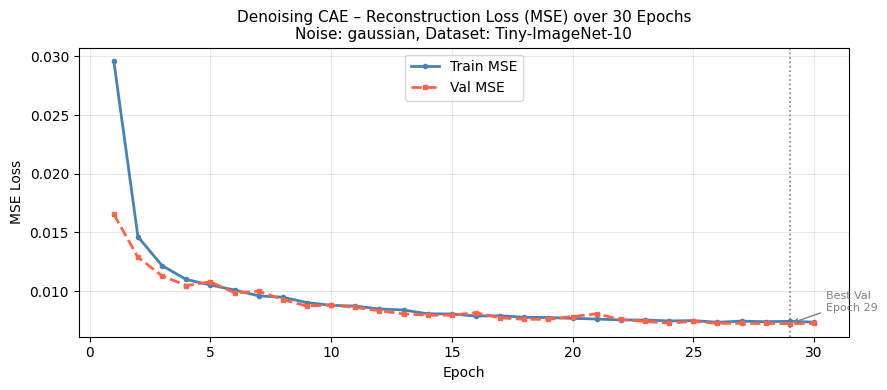

Loss curve saved to loss_curve_dae.png


In [34]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(epochs_range, train_losses, label='Train MSE', color='steelblue',
        linewidth=2, marker='o', markersize=3)
ax.plot(epochs_range, val_losses,   label='Val MSE',   color='tomato',
        linewidth=2, marker='s', markersize=3, linestyle='--')

# Annotate minimum validation loss
best_epoch = int(np.argmin(val_losses)) + 1
ax.axvline(best_epoch, color='grey', linestyle=':', linewidth=1.2)
ax.annotate(f'Best Val\nEpoch {best_epoch}',
            xy=(best_epoch, min(val_losses)),
            xytext=(best_epoch + 1.5, min(val_losses) * 1.15),
            fontsize=8, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey'))

ax.set_title(f'Denoising CAE – Reconstruction Loss (MSE) over {NUM_EPOCHS} Epochs\n'
             f'Noise: {NOISE_TYPE}, Dataset: Tiny-ImageNet-10', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_dae.png', dpi=150)
plt.show()
print('Loss curve saved to loss_curve_dae.png')

## 8. Reconstruction Trio: Original | Noisy | Denoised

We load the **best checkpoint** and display the required trio for several images.

Best model loaded.


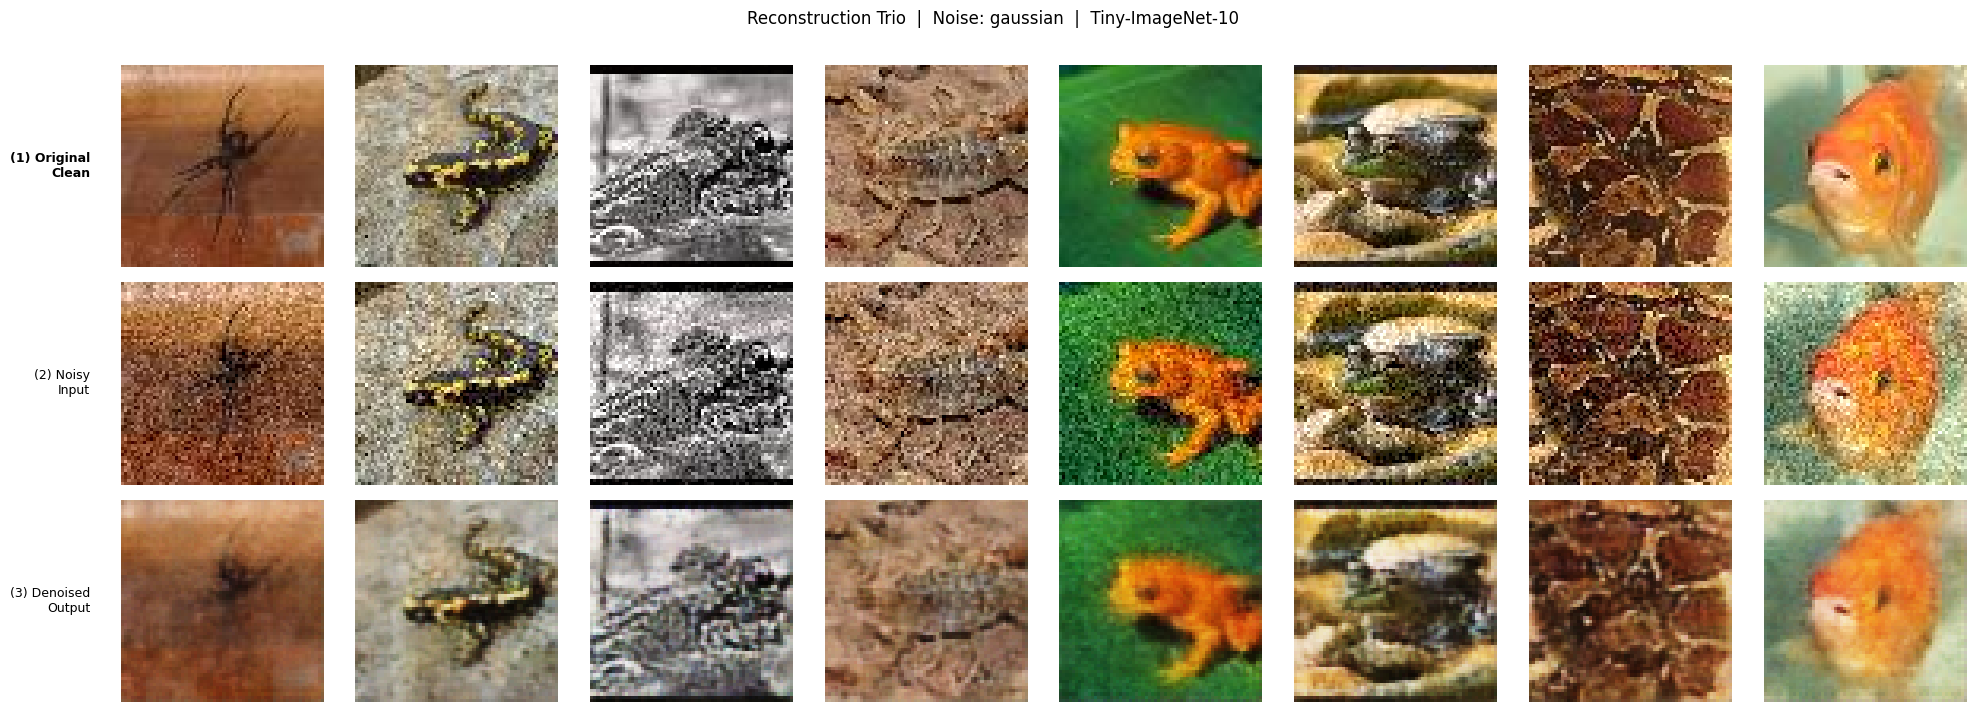

Saved to reconstruction_trio.png


In [35]:
# ── Load best model ───────────────────────────────────────────────────────────
# Added weights_only=True to avoid deprecation warning in PyTorch >= 2.0 and
# to prevent arbitrary code execution from untrusted checkpoint files.
model.load_state_dict(torch.load('best_dae.pth', map_location=DEVICE, weights_only=True))
model.eval()
print('Best model loaded.')


def tensor_to_img(t):
    """Convert a (C, H, W) tensor in [0,1] to a NumPy (H, W, C) uint8 array."""
    return (t.permute(1, 2, 0).cpu().clamp(0, 1).numpy() * 255).astype(np.uint8)


def show_reconstruction_trio(clean_batch, noisy_batch, recon_batch,
                              n_images=8, figsize=(20, 7)):
    """
    Display a grid of (Original Clean | Noisy Input | Denoised Output).

    Args:
        clean_batch : (N, C, H, W) clean images
        noisy_batch : (N, C, H, W) noisy inputs
        recon_batch : (N, C, H, W) model reconstructions
        n_images    : number of images to display
    """
    n_images = min(n_images, clean_batch.size(0))

    fig, axes = plt.subplots(3, n_images, figsize=figsize)

    row_labels = ['(1) Original\nClean',
                  '(2) Noisy\nInput',
                  '(3) Denoised\nOutput']
    batches = [clean_batch, noisy_batch, recon_batch]

    for row, (batch, row_label) in enumerate(zip(batches, row_labels)):
        for col in range(n_images):
            ax = axes[row, col]
            ax.imshow(tensor_to_img(batch[col]))
            ax.axis('off')

        # Use transAxes to place label reliably outside the image boundary
        axes[row, 0].text(
            -0.15, 0.5, row_label,
            transform=axes[row, 0].transAxes,
            fontsize=9, va='center', ha='right',
            fontweight='bold' if row == 0 else 'normal'
        )

    plt.suptitle(
        f'Reconstruction Trio  |  Noise: {NOISE_TYPE}  |  Tiny-ImageNet-10',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig('reconstruction_trio.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to reconstruction_trio.png')


# ── Generate trio ─────────────────────────────────────────────────────────────
test_batch, _ = next(iter(val_loader))
test_clean    = test_batch[:8].to(DEVICE)
test_noisy    = add_noise(test_clean, NOISE_TYPE)

with torch.no_grad():
    test_recon = model(test_noisy)

show_reconstruction_trio(test_clean, test_noisy, test_recon, n_images=8)

## 9. Extended Experiment – Both Noise Types

Below we visualise what the **same trained model** does when presented with each noise type independently, to illustrate its generalisation.

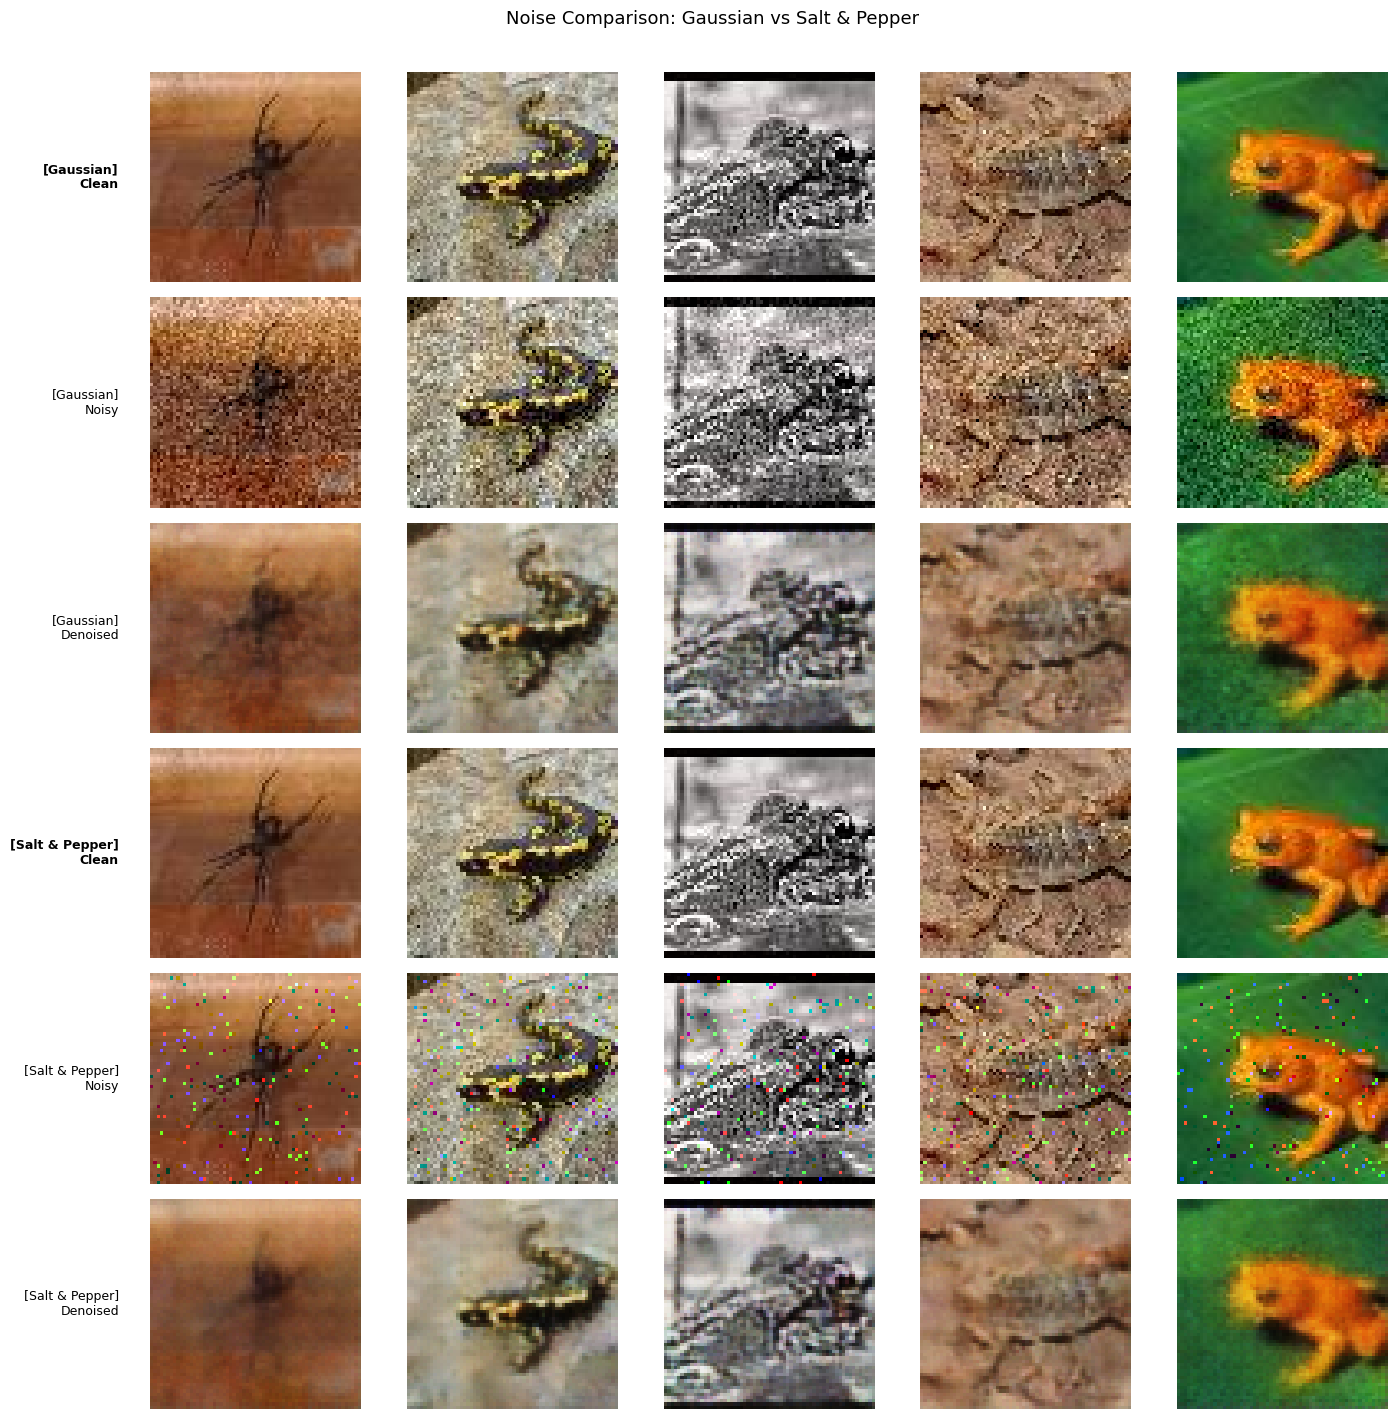

In [36]:
def show_noise_comparison(clean_imgs, model, n=5):
    clean_imgs = clean_imgs[:n].to(DEVICE)
    noise_types = ['gaussian', 'salt_pepper']

    fig, axes = plt.subplots(len(noise_types) * 3, n,
                             figsize=(n * 2.5 + 2, len(noise_types) * 7))

    row_labels = [
        '[Gaussian]\nClean', '[Gaussian]\nNoisy', '[Gaussian]\nDenoised',
        '[Salt & Pepper]\nClean', '[Salt & Pepper]\nNoisy', '[Salt & Pepper]\nDenoised'
    ]

    model.eval()
    for noise_idx, nt in enumerate(noise_types):
        noisy = add_noise(clean_imgs, noise_type=nt)
        with torch.no_grad():
            recon = model(noisy)

        batches = [clean_imgs, noisy, recon]
        sub_labels = ['Clean', 'Noisy', 'Denoised']

        for row_offset, (batch, sub_lbl) in enumerate(zip(batches, sub_labels)):
            row = noise_idx * 3 + row_offset
            for col in range(n):
                ax = axes[row, col]
                ax.imshow(tensor_to_img(batch[col]))
                ax.axis('off')

            # Add label as text to the left of the first image in each row
            axes[row, 0].text(
                -0.15, 0.5, row_labels[row],
                transform=axes[row, 0].transAxes,
                fontsize=9, va='center', ha='right',
                fontweight='bold' if sub_lbl == 'Clean' else 'normal'
            )

    plt.suptitle('Noise Comparison: Gaussian vs Salt & Pepper', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('noise_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


show_noise_comparison(test_clean, model, n=5)

## 10. Quantitative Evaluation

In [38]:
def evaluate_mse(loader, model, noise_type):
    """
    Compute average MSE between denoised output and clean images
    over the entire provided DataLoader.
    """
    model.eval()
    total_mse = 0.0
    with torch.no_grad():
        for clean, _ in loader:
            clean = clean.to(DEVICE)
            noisy = add_noise(clean, noise_type)
            recon = model(noisy)
            total_mse += criterion(recon, clean).item() * clean.size(0)
    return total_mse / len(loader.dataset)

# Note: model was trained on Gaussian noise only.
# Evaluating on all three noise types to test generalisation.
print('Evaluation on validation set (best model):')
print(f'  Gaussian noise MSE    : {evaluate_mse(val_loader, model, "gaussian"):.6f}')
print(f'  Salt & Pepper MSE     : {evaluate_mse(val_loader, model, "salt_pepper"):.6f}')
print(f'  Combined noise MSE    : {evaluate_mse(val_loader, model, "both"):.6f}')


Evaluation on validation set (best model):
  Gaussian noise MSE    : 0.007223
  Salt & Pepper MSE     : 0.006731
  Combined noise MSE    : 0.007857


# Deep Learning Assignment – Part 3



In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="C:/Users/aashv/Downloads/MNIST/MNIST",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="C:/Users/aashv/Downloads/MNIST/MNIST",
    train=False,   # IMPORTANT: False for test set
    download=True,
    transform=transform
) 

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)   

In [12]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

model = Autoencoder()

In [13]:
criterion = nn.MSELoss()  # Reconstruction Loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [14]:
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0
    
    for images, _ in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, images)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/30], Loss: 0.0709
Epoch [2/30], Loss: 0.0544
Epoch [3/30], Loss: 0.0518
Epoch [4/30], Loss: 0.0502
Epoch [5/30], Loss: 0.0492
Epoch [6/30], Loss: 0.0483
Epoch [7/30], Loss: 0.0476
Epoch [8/30], Loss: 0.0469
Epoch [9/30], Loss: 0.0464
Epoch [10/30], Loss: 0.0459
Epoch [11/30], Loss: 0.0455
Epoch [12/30], Loss: 0.0451
Epoch [13/30], Loss: 0.0448
Epoch [14/30], Loss: 0.0445
Epoch [15/30], Loss: 0.0442
Epoch [16/30], Loss: 0.0440
Epoch [17/30], Loss: 0.0438
Epoch [18/30], Loss: 0.0436
Epoch [19/30], Loss: 0.0434
Epoch [20/30], Loss: 0.0433
Epoch [21/30], Loss: 0.0431
Epoch [22/30], Loss: 0.0430
Epoch [23/30], Loss: 0.0429
Epoch [24/30], Loss: 0.0428
Epoch [25/30], Loss: 0.0427
Epoch [26/30], Loss: 0.0426
Epoch [27/30], Loss: 0.0424
Epoch [28/30], Loss: 0.0424
Epoch [29/30], Loss: 0.0423
Epoch [30/30], Loss: 0.0422


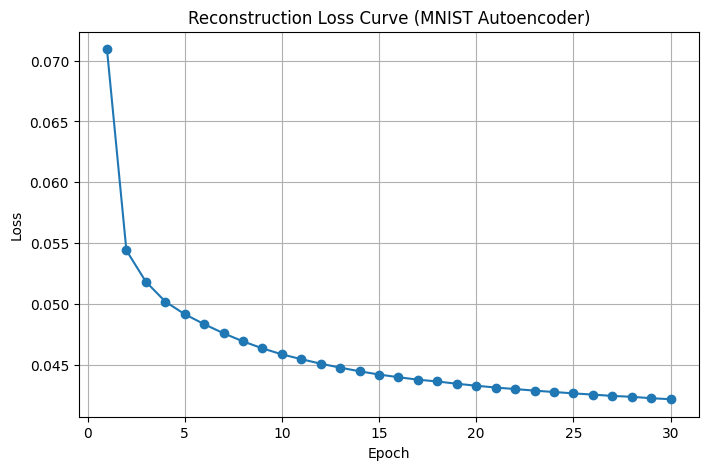

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), loss_history, marker='o')

plt.title("Reconstruction Loss Curve (MNIST Autoencoder)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [17]:
latent_vectors = []
labels = []

with torch.no_grad():
    for images, lbls in test_loader:
        z = model.encoder(images)
        latent_vectors.append(z)
        labels.append(lbls)

latent_vectors = torch.cat(latent_vectors).numpy()
labels = torch.cat(labels).numpy()

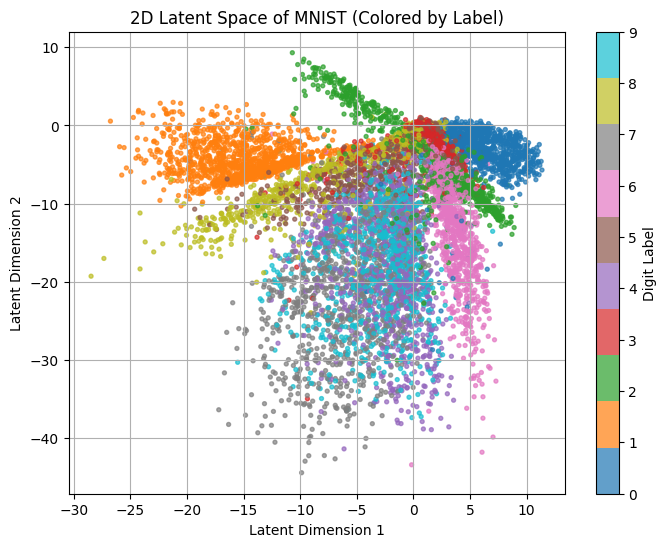

In [18]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_vectors[:, 0],
    latent_vectors[:, 1],
    c=labels,
    cmap='tab10',
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, label="Digit Label")
plt.title("2D Latent Space of MNIST (Colored by Label)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)

plt.show()

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="C:/Users/aashv/Downloads/MNIST/MNIST",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="C:/Users/aashv/Downloads/MNIST/MNIST",
    train=False,   # IMPORTANT: False for test set
    download=True,
    transform=transform
) 

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)   

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Tanh()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

model = Autoencoder()

In [4]:
criterion = nn.MSELoss()  # Reconstruction Loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0
    
    for images, _ in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, images)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/30], Loss: 0.0588
Epoch [2/30], Loss: 0.0482
Epoch [3/30], Loss: 0.0466
Epoch [4/30], Loss: 0.0456
Epoch [5/30], Loss: 0.0450
Epoch [6/30], Loss: 0.0444
Epoch [7/30], Loss: 0.0440
Epoch [8/30], Loss: 0.0436
Epoch [9/30], Loss: 0.0433
Epoch [10/30], Loss: 0.0431
Epoch [11/30], Loss: 0.0428
Epoch [12/30], Loss: 0.0426
Epoch [13/30], Loss: 0.0425
Epoch [14/30], Loss: 0.0423
Epoch [15/30], Loss: 0.0421
Epoch [16/30], Loss: 0.0420
Epoch [17/30], Loss: 0.0419
Epoch [18/30], Loss: 0.0417
Epoch [19/30], Loss: 0.0416
Epoch [20/30], Loss: 0.0415
Epoch [21/30], Loss: 0.0414
Epoch [22/30], Loss: 0.0413
Epoch [23/30], Loss: 0.0412
Epoch [24/30], Loss: 0.0411
Epoch [25/30], Loss: 0.0410
Epoch [26/30], Loss: 0.0409
Epoch [27/30], Loss: 0.0408
Epoch [28/30], Loss: 0.0407
Epoch [29/30], Loss: 0.0407
Epoch [30/30], Loss: 0.0406


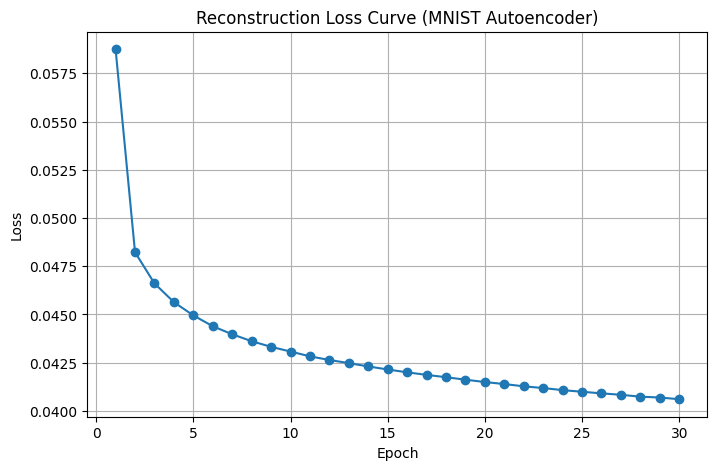

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), loss_history, marker='o')

plt.title("Reconstruction Loss Curve (MNIST Autoencoder)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [7]:
latent_vectors = []
labels = []

with torch.no_grad():
    for images, lbls in test_loader:
        z = model.encoder(images)
        latent_vectors.append(z)
        labels.append(lbls)

latent_vectors = torch.cat(latent_vectors).numpy()
labels = torch.cat(labels).numpy()

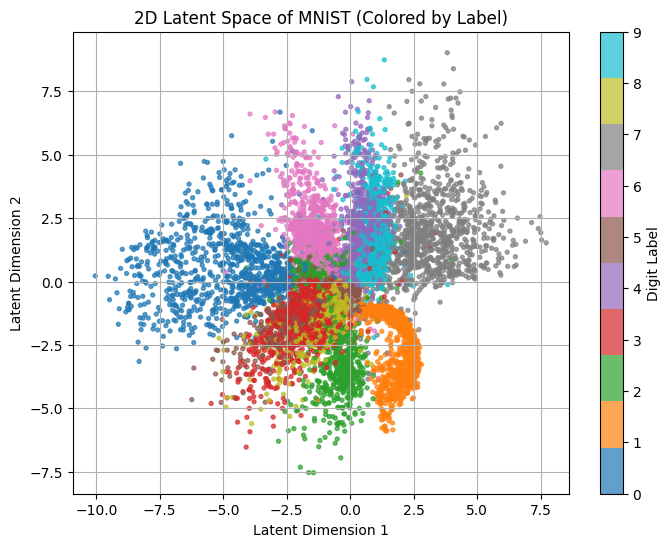

In [8]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_vectors[:, 0],
    latent_vectors[:, 1],
    c=labels,
    cmap='tab10',
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, label="Digit Label")
plt.title("2D Latent Space of MNIST (Colored by Label)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)

plt.show()

# Q3.2

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Section 1 — Data Loading (Normalized to [0, 1])

`transforms.ToTensor()` automatically scales pixel values from [0, 255] to [0, 1].  

- Sigmoid outputs values in **[0, 1]**.
- The MSE loss compares output vs target — both must be in **[0, 1]** for the loss to be meaningful.


In [4]:
# Transform: pixels scaled to [0, 1] only — required for Sigmoid final activation
transform_01 = transforms.Compose([
    transforms.ToTensor()  # Converts to [0, 1]; no further normalization
])

# Load datasets
train_dir = 'tiny-imagenet/train'
test_dir  = 'tiny-imagenet/test'

full_train_data = datasets.ImageFolder(root=train_dir, transform=transform_01)
full_test_data  = datasets.ImageFolder(root=test_dir,  transform=transform_01)

# Define anomaly class (10th class withheld during training)
anomaly_class_name = 'n12267677'
anomaly_idx = full_test_data.class_to_idx[anomaly_class_name]
print(f'Anomaly class index: {anomaly_idx}  ({anomaly_class_name})')

# --- Training data: only 9 seen classes ---
seen_train_indices   = [i for i, label in enumerate(full_train_data.targets) if label != anomaly_idx]
train_data_seen      = Subset(full_train_data, seen_train_indices)

# --- Test data: split into seen and unseen ---
seen_test_indices    = [i for i, label in enumerate(full_test_data.targets) if label != anomaly_idx]
unseen_test_indices  = [i for i, label in enumerate(full_test_data.targets) if label == anomaly_idx]

test_data_seen       = Subset(full_test_data, seen_test_indices)
test_data_unseen     = Subset(full_test_data, unseen_test_indices)

# DataLoaders
batch_size = 64
train_loader        = DataLoader(train_data_seen,   batch_size=batch_size, shuffle=True,  num_workers=2)
test_seen_loader    = DataLoader(test_data_seen,    batch_size=batch_size, shuffle=False, num_workers=2)
test_unseen_loader  = DataLoader(test_data_unseen,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Training samples (9 seen classes): {len(train_data_seen)}')
print(f'Test samples (seen):   {len(test_data_seen)}')
print(f'Test samples (unseen): {len(test_data_unseen)}')

Anomaly class index: 9  (n12267677)
Training samples (9 seen classes): 3150
Test samples (seen):   900
Test samples (unseen): 100


## CAE Architecture


In [ ]:
class CAE(nn.Module):
    """
    Convolutional Autoencoder for 64x64 RGB images.
    Encoder: 64x64 -> 32x32 -> 16x16 -> 8x8
    Decoder: 8x8   -> 16x16 -> 32x32 -> 64x64

    Args:
        final_activation: nn.Sigmoid() for [0,1] output,
                          nn.Tanh()    for [-1,1] output.
    """
    def __init__(self, final_activation):
        super(CAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # -> 32x32
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 8x8
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(16,  3, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 64x64
            final_activation  # Sigmoid -> [0,1]  
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


def build_model(activation_name='sigmoid'):
    """Helper to build a CAE with the chosen final activation."""
    if activation_name == 'sigmoid':
        act = nn.Sigmoid()
    elif activation_name == 'tanh':
        act = nn.Tanh()
    else:
        raise ValueError(f"Unknown activation: {activation_name}")
    return CAE(final_activation=act).to(device)

## Training Function

In [6]:
def train_model(model, loader, epochs=30, lr=1e-3):
    """
    Trains a CAE using Adam + MSE loss.
    Returns the per-epoch loss history.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, _ in loader:
            images = images.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)  # Reconstruct clean image
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        loss_history.append(epoch_loss)
        print(f'  Epoch [{epoch+1:02d}/{epochs}]  Loss: {epoch_loss:.4f}')

    return loss_history

## Train CAE with Sigmoid (Anomaly Detection)

Train on **9 seen classes** only.  
Sigmoid outputs **[0, 1]**, which matches our **[0, 1]** normalized input — MSE loss is well-defined.

In [7]:
print('=== Training CAE with Sigmoid (Q3.2) ===')
model_sigmoid = build_model('sigmoid')
history_sigmoid = train_model(model_sigmoid, train_loader, epochs=30)

=== Training CAE with Sigmoid (Q3.2) ===
  Epoch [01/30]  Loss: 0.0609
  Epoch [02/30]  Loss: 0.0303
  Epoch [03/30]  Loss: 0.0239
  Epoch [04/30]  Loss: 0.0180
  Epoch [05/30]  Loss: 0.0155
  Epoch [06/30]  Loss: 0.0145
  Epoch [07/30]  Loss: 0.0141
  Epoch [08/30]  Loss: 0.0137
  Epoch [09/30]  Loss: 0.0132
  Epoch [10/30]  Loss: 0.0131
  Epoch [11/30]  Loss: 0.0128
  Epoch [12/30]  Loss: 0.0126
  Epoch [13/30]  Loss: 0.0121
  Epoch [14/30]  Loss: 0.0119
  Epoch [15/30]  Loss: 0.0118
  Epoch [16/30]  Loss: 0.0116
  Epoch [17/30]  Loss: 0.0114
  Epoch [18/30]  Loss: 0.0113
  Epoch [19/30]  Loss: 0.0111
  Epoch [20/30]  Loss: 0.0111
  Epoch [21/30]  Loss: 0.0109
  Epoch [22/30]  Loss: 0.0108
  Epoch [23/30]  Loss: 0.0108
  Epoch [24/30]  Loss: 0.0105
  Epoch [25/30]  Loss: 0.0104
  Epoch [26/30]  Loss: 0.0105
  Epoch [27/30]  Loss: 0.0101
  Epoch [28/30]  Loss: 0.0100
  Epoch [29/30]  Loss: 0.0100
  Epoch [30/30]  Loss: 0.0099


### Reconstruction Loss Curve

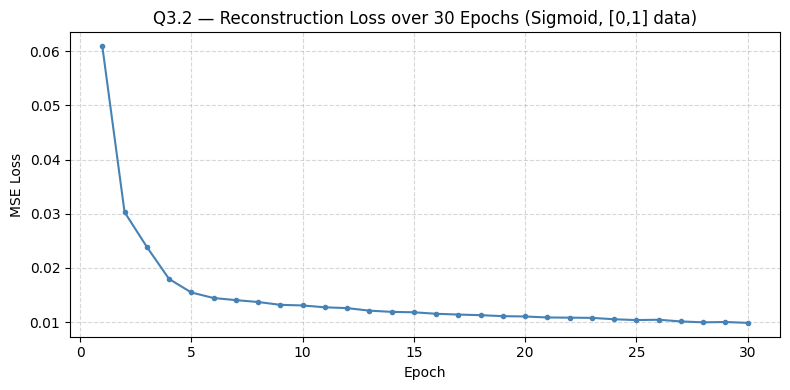

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 31), history_sigmoid, marker='o', markersize=3, color='steelblue')
plt.title('Q3.2 — Reconstruction Loss over 30 Epochs (Sigmoid, [0,1] data)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Reconstruction Error: Seen vs Unseen Classes

In [16]:
def calculate_errors(loader, model):
    """
    Computes per-image MSE reconstruction error for all images in the loader.
    Returns a list of floats.
    """
    criterion = nn.MSELoss(reduction='mean')
    model.eval()
    errors = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            for i in range(images.size(0)):
                err = criterion(outputs[i], images[i]).item()
                errors.append(err)
    return errors


# Compute errors
seen_errors   = calculate_errors(test_seen_loader,   model_sigmoid)
unseen_errors = calculate_errors(test_unseen_loader, model_sigmoid)

print(f'Average MSE — Seen Classes  (9 classes): {np.mean(seen_errors):.4f}')
print(f'Average MSE — Unseen Class (anomaly):    {np.mean(unseen_errors):.4f}')

Average MSE — Seen Classes  (9 classes): 0.0096
Average MSE — Unseen Class (anomaly):    0.0122


### Histogram: Reconstruction Error Distribution

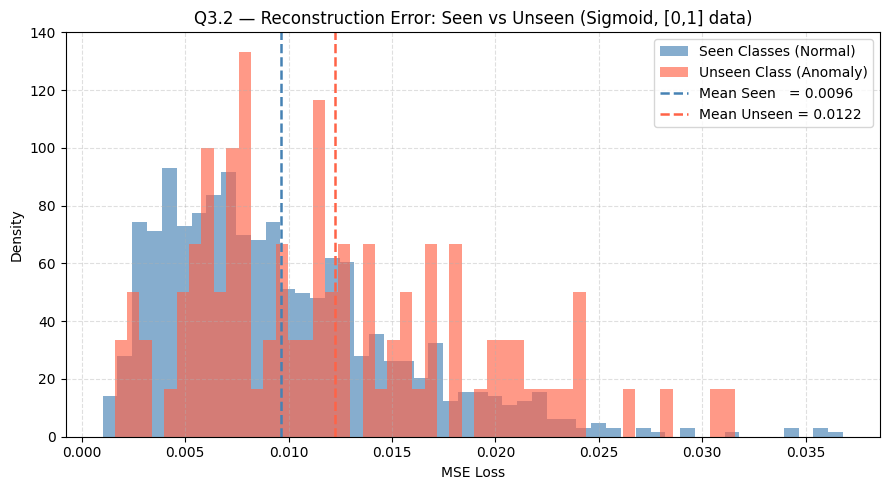


Observation:
The unseen (anomaly) class has a HIGHER average reconstruction error.
This confirms that the autoencoder, trained only on seen classes, struggles
to reconstruct images from the novel class it has never seen during training.


In [10]:
plt.figure(figsize=(9, 5))
plt.hist(seen_errors,   bins=50, alpha=0.65, label='Seen Classes (Normal)',  density=True, color='steelblue')
plt.hist(unseen_errors, bins=50, alpha=0.65, label='Unseen Class (Anomaly)', density=True, color='tomato')

# Mark the means
plt.axvline(np.mean(seen_errors),   color='steelblue', linestyle='--', linewidth=1.8,
            label=f'Mean Seen   = {np.mean(seen_errors):.4f}')
plt.axvline(np.mean(unseen_errors), color='tomato',    linestyle='--', linewidth=1.8,
            label=f'Mean Unseen = {np.mean(unseen_errors):.4f}')

plt.title('Q3.2 — Reconstruction Error: Seen vs Unseen (Sigmoid, [0,1] data)')
plt.xlabel('MSE Loss')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nObservation:')
print('The unseen (anomaly) class has a HIGHER average reconstruction error.')
print('This confirms that the autoencoder, trained only on seen classes, struggles')
print('to reconstruct images from the novel class it has never seen during training.')

#### OBSERVATION

Yes, the reconstruction error can be used to identify that the 10th class is different from the others.

The autoencoder is trained only on the 9 seen classes, so it learns the patterns and features of those classes. Because of this, it can reconstruct images from these seen classes accurately, resulting in a low reconstruction error.

However, the 10th class is not present during training. When images from this unseen class are passed through the autoencoder, the model cannot represent them properly. As a result, the reconstructed image differs more from the original image, producing a higher reconstruction error.

Therefore, when we compare the errors, the seen classes have lower reconstruction error, while the unseen class has significantly higher reconstruction error. This difference in reconstruction error can be used to detect that the 10th class is different and treat it as an anomaly.

## Part 3.2: Anomaly Detection using Autoencoder

We evaluate whether reconstruction error can identify out-of-distribution samples by training on 9 classes and testing on an unseen 10th class.

### Step 1: Data Preparation

Images are kept in the range [0,1]. Since Tanh outputs [-1,1], we rescale outputs back to [0,1] before computing loss.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.ToTensor()

train_dir = 'tiny-imagenet/train'
test_dir = 'tiny-imagenet/test'

train_data_full = datasets.ImageFolder(train_dir, transform=transform)
test_data_full = datasets.ImageFolder(test_dir, transform=transform)

anomaly_class = 'n12267677'
anomaly_idx = train_data_full.class_to_idx[anomaly_class]

train_idx = [i for i, y in enumerate(train_data_full.targets) if y != anomaly_idx]
seen_idx = [i for i, y in enumerate(test_data_full.targets) if y != anomaly_idx]
unseen_idx = [i for i, y in enumerate(test_data_full.targets) if y == anomaly_idx]

train_data = Subset(train_data_full, train_idx)
test_seen = Subset(test_data_full, seen_idx)
test_unseen = Subset(test_data_full, unseen_idx)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
seen_loader = DataLoader(test_seen, batch_size=64)
unseen_loader = DataLoader(test_unseen, batch_size=64)

### Step 2: Model Architecture

A convolutional autoencoder compresses the image into a latent space and reconstructs it. Tanh is used at output and rescaled.

In [5]:
class CAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, 2, 1, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, 2, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return (x + 1) / 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CAE().to(device)

### Step 3: Training

We train using MSE loss for 30 epochs and track reconstruction loss.

1 0.05900560706144287
2 0.02290412321331955
3 0.017155362142929956
4 0.015085968593401567
5 0.014109130038746765
6 0.013410621458694103
7 0.013032776974141598
8 0.012737387191681635
9 0.012360170028275913
10 0.011961948444091139
11 0.011714879214054062
12 0.01140805110039692
13 0.011037703578670819
14 0.010815420327560296
15 0.010630945840052195
16 0.010491038075988255
17 0.010266242607954949
18 0.010135465774626012
19 0.010089703053827323
20 0.009851977677335816
21 0.009691276873742776
22 0.009593413009175232
23 0.009450217473010222
24 0.009331854208121224
25 0.009152976034416093
26 0.009074157941199484
27 0.00882840045506046
28 0.008780419441560904
29 0.00867000035764206
30 0.008465299977078324


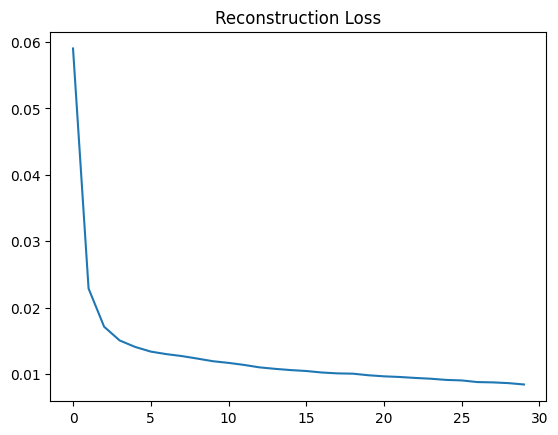

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

losses = []

for epoch in range(30):
    total = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, x)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.size(0)

    epoch_loss = total / len(train_loader.dataset)
    losses.append(epoch_loss)
    print(epoch+1, epoch_loss)

plt.plot(losses)
plt.title('Reconstruction Loss')
plt.show()

### Step 4: Evaluation

Reconstruction error is computed per image. Higher values indicate anomalies.

In [7]:
def get_errors(loader):
    errors = []
    model.eval()
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            out = model(x)
            loss = ((out - x)**2).mean(dim=[1,2,3])
            errors.extend(loss.cpu().numpy())
    return errors

seen_err = get_errors(seen_loader)
unseen_err = get_errors(unseen_loader)

print('Seen:', np.mean(seen_err))
print('Unseen:', np.mean(unseen_err))

threshold = np.percentile(seen_err, 95)
print('Threshold:', threshold)

Seen: 0.00839775
Unseen: 0.009797837
Threshold: 0.01848543


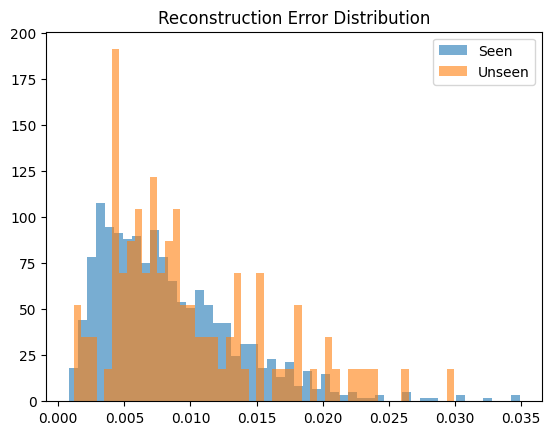

In [8]:
plt.hist(seen_err, bins=50, alpha=0.6, label='Seen', density=True)
plt.hist(unseen_err, bins=50, alpha=0.6, label='Unseen', density=True)
plt.legend()
plt.title('Reconstruction Error Distribution')
plt.show()

### Conclusion

Unseen samples show higher reconstruction error, indicating that the model detects distributional differences. However, overlap exists, so anomaly detection is probabilistic rather than exact.